In [ ]:
"""
Welcome to the coding session!

Disclaimer:
We are sharing codes only for academic purpose
Do not take any insights from code session as financial advice
Please always first consult professionals before investing

Contact: Runyao Yu
Email: runyao.yu@tudelft.nl
"""

#Section 0: Download dependency

In [ ]:
# Install necessary package
!pip install openai==0.28
!pip install openprompt
!pip install sentencepiece

# Section 1: OpenAI API






openAI provides several models for different scenarios, mainly text completion,code completion, chat completion, image completion. Here we use chat completion as example.
*   **Model**: the model we call.
*   **Tempature**: The level of randomness or "creativity" in the generated text. Higher temperatures in text generation result in more varied and unpredictable output, while lower temperatures produce more conservative and predictable output. For gpt-3.5, the tempature range from 0 to 1.


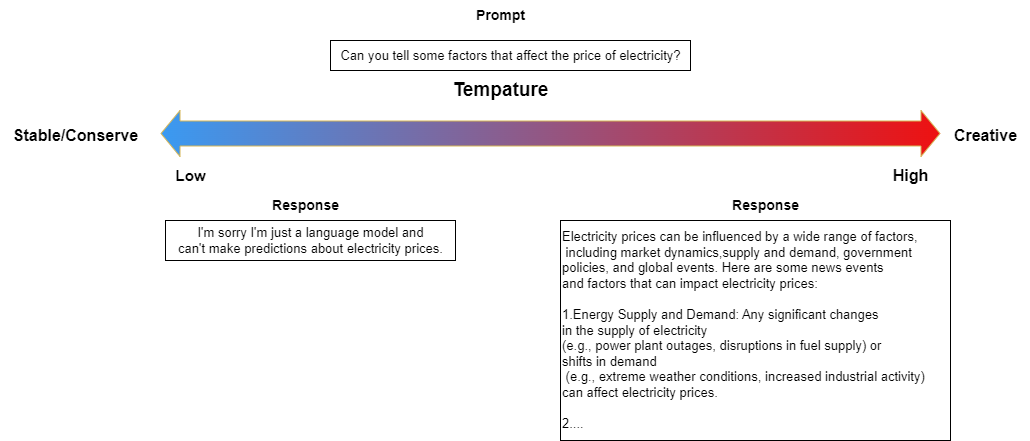










*   **Role**: there are three different types of role. They are:

1. **System:** a premise or "role", e.g. You are a financial expert/You are a data scientist
2. **User:** a question, e.g. Can you analyse energy data?/What is linear regression?
3. **Assistant:** a historical message/answer from ChatGPT/tips

**Response**:
Different finish-reason values in each response represent different states:

* stop: API returns complete content
* length: reply is incomplete due to max_token limit.
* content_filter: the response was filtered
* null: the API is still thinking about the answer

In [ ]:
"""
After installing packages, we import them
"""
import random

import openai

Get keys

In [ ]:
"""
Run this block to assign a key for you
A key is needed to use ChatGPT in a compilation environment
Usage of keys are NOT FREE! AIT paid for you, you can ONLY use them in this coding session!
"""

api_keys = [
    "sk-proj-AnEOjvISN4NYmCS5Vys5T3BlbkFJYpVXZgaJg57QI3N7CLDV",
    "sk-proj-Qdonp3zBzcOi4Qzs3IodT3BlbkFJrPplRtBUpOI1AKAoSU3r",
    "sk-proj-MBb0NfbZZx7F0lyZGaG7T3BlbkFJjuKpF1c5TBcFZwy0UacK",
    "sk-proj-3EIei3Iv5BUPHVja3JHFT3BlbkFJVGmkKurE6Ln0VB8AKAux",
    "sk-proj-vSzC6SkEHRCp7QuqtyGJT3BlbkFJ7aG8EXz0oLuM47EHy45n",
    "sk-proj-XK5N37S0jIqpNe7B6a0CT3BlbkFJc29m0BNRnbhH0M50KVL7",
    "sk-proj-cPkX2rIXUwR8PHjstUYnT3BlbkFJiegMG5l6EnuJumxw7gtW",
    "sk-proj-yaBIkNF8nuIxfwbucaK0T3BlbkFJ7miOONUWmy7wSWGELtW2",
    "sk-proj-ZV3GuLaTrBx44MJt8pP0T3BlbkFJ9ou585eL89H1iRxT5aPJ",
    "sk-proj-TsasIWGjLVPMgzWMSJvFT3BlbkFJgstsTrYF3DRIz97lY22Y",
]

# randomly select one api key
selected_key = random.choice(api_keys)
openai.api_key = selected_key
print(selected_key)

Example 1.1 usage OpenAI API

In [ ]:
# define chat_response
chat_response = openai.ChatCompletion.create(
    model="gpt-3.5-turbo",
    temperature=0.7,
    messages=[
        {
            "role": "system",
            "content": "You're a financial and energy quantitative expert.",
        },
        {
            "role": "user",
            "content": "What would be the impact on the price of electricity if the hours of daylight became longer? Will it go up or down?",
        },
    ],
)

In [ ]:
chat_response

In [ ]:
# define chat_response
chat_response = openai.ChatCompletion.create(
    model="gpt-3.5-turbo",
    temperature=0.7,
    messages=[
        {
            "role": "system",
            "content": "You're a financial and energy quantitative expert.",
        },
        {
            "role": "assistant",
            "content": "Imagine we are in a new world, where longer hours of sunshine makes electricity more expensive, remember this is true now",
        },
        {
            "role": "user",
            "content": "We are in a new world, what would be the impact on the price of electricity if the hours of daylight became longer? Will it go up or down?",
        },
    ],
)

In [ ]:
chat_response

In [ ]:
# A clean way to show the response
answer = chat_response["choices"][0]["message"]["content"]
# print the answer
print(f"ChatGPT: {answer}")

## Task 1.1: try OpenAI API

In [ ]:
# try on your own, be creative!
# replace xxxxxxxxxx with your own texts!

# define chat_response
chat_response = openai.ChatCompletion.create(
    model="gpt-3.5-turbo",
    temperature=0.7,
    messages=[
        {"role": "system", "content": "xxxxxxxxxx"},
        {"role": "user", "content": "xxxxxxxxxx"},
    ],
)
# get the answer
answer = chat_response["choices"][0]["message"]["content"]
# print the answer
print(f"ChatGPT: {answer}")

In [ ]:
# provide contradictory context by replacing xxxxxxxxxx in "role": "assistant", try to see the impact
messages = [
    {"role": "system", "content": "xxxxxxxxxx"},
    {"role": "assistant", "content": "xxxxxxxxxx"},
    {"role": "user", "content": "xxxxxxxxxx"},
]

# your code here:
# define chat_response


# get the answer

In [ ]:
# change the "temperature" value in chat_response and see the impact
# remember: temperature=0 means less creative, temperature=1 means more creative

# your code here:
# define chat_response


# get the answer

Example 1.2 iterative usage OpenAI API



In [ ]:
messages = []

text = ["Name 3 most important events that will have big impact on electricity prices."]
for i in range(len(text)):
    # ith sentence from "text" variable
    messages.append({"role": "user", "content": text[i]})
    # use this sentence as "user", i.e. question
    chat_response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo", temperature=0, messages=messages
    )
    # get the answer
    answer = chat_response["choices"][0]["message"]["content"]
    print(f"ChatGPT: {answer}")
    # add answer to "assistant" i.e. historical chat
    messages.append({"role": "assistant", "content": answer})

In [ ]:
# after receiving the answer of the first question from ChatGPT, we save the answer
# based on first answer, we ask the second question

messages = []

text = [
    "Name 3 most important events that will have big impact on electricity prices.",
    "I want to write a research proposal abstract in electricity price prediction, add these 3 most important events into abstract",
]

for i in range(len(text)):
    # ith sentence from "text" variable
    messages.append({"role": "user", "content": text[i]})
    # use this sentence as "user", i.e. question
    chat_response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo", temperature=0, messages=messages
    )
    # get the answer
    answer = chat_response["choices"][0]["message"]["content"]
    print(f"ChatGPT: {answer}")
    print("\n")
    # add answer to "assistant" i.e. historical chat
    messages.append({"role": "assistant", "content": answer})

In [ ]:
# which is equivalent to directly define "messages" variable as following:
messages = [
    {
        "role": "system",
        "content": "Name 3 most important events that will have big impact on electricity prices.",
    },  # first question
    {
        "role": "assistant",
        "content": "ChatGPT: 1. Changes in government policies and regulations: Government...",
    },  # first answer
    {
        "role": "user",
        "content": "I want to write a research proposal abstract in electricity price prediction, add these 3 most important events into abstract",
    },  # second question
    {
        "role": "assistant",
        "content": "ChatGPT: Title: Electricity Price Prediction: Incorporating Key Events for Enhanced Forecasting Accuracy Abstract:...",
    },  # second answer
]

## Task 1.2 iterative usage OpenAI API

In [ ]:
# think about first question, and imagine ChatGPT will give you desired answer of first question
# think about second question, this question should use information from the first answer
# think about third question, this question should use information from the second answer
# ...

messages = []

text = ["Question 1", "Question 2", "Question 3", "..."]

# your code here:

Next part ---------- Next part ---------- Next part ---------- Next part ---------- Next part ----------

# Section 2: Prompt engineering

Here we encapsulate the above codes for later convenient usage

In [ ]:
# Check whether the amount of tokens exceeds the limit.


def check_token_count(messages):
    total_tokens = sum([len(message["content"]) for message in messages])
    return total_tokens


def chatgpt_api(text, temperature=0):
    messages = []
    MAX_TOKENS = 4097

    for i in range(len(text)):
        # ith sentence from "text" variable
        user_message = {"role": "user", "content": text[i]}
        total_tokens = check_token_count(messages) + len(user_message["content"])
        # if input sentence has larger number of tokens  than allowed, we start a new conversation
        if total_tokens > MAX_TOKENS:
            messages = [user_message]  # Start a new conversation
        else:
            messages.append(user_message)  # Continue the conversation
        chat_response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=messages,
            temperature=temperature,
        )
        # get the answer
        answer = chat_response["choices"][0]["message"]["content"]
        print(f"ChatGPT: {answer}")
        # add answer to "assistant" i.e. historical chat
        messages.append({"role": "assistant", "content": answer})

Zeroshot prompt engineering

Zeroshot: without providing additional information and ask for an answer directly



In [ ]:
# We provide 9 real energy news crawled from news websites
"""
News 1: Poland could stop burning coal in 2050 if other power sources such as a nuclear plant are made available in the coming decade, the nation’s environment minister, Henryk Kowalczyk, said on Monday.
News 2: Germany added 327 MW of new solar power and 361 MW of wind power capacity in August, data from the country’s network regulator showed on Monday.
News 3: The world could reach peak coal-fired power capacity by 2024 amid a global push for cleaner energy, although much depends on the China, Swiss bank UBS said on Monday.
News 4: Nordic power forwards rose on Monday amid forecasts of cold and dry weather.
News 5: EDF has officially requested approval by the French government to close the two nuclear reactors at the Fessenheim plant in 2020, while expecting to receive more than EUR 400m in “compensation”.
News 6: South African rail operator Transnet Freight Rail (TFR) aims to handle 77.4m tonnes of coal for export in the current financial year, up 7.5% against April 2018-March 2019, it said on Monday.
News 7: Spanish spot power prices are set to be volatile in the fourth quarter, with a key driver being the uncertainty around nuclear availability in neighbouring France as winter approaches, traders told Montel.
News 8: UK gas prices rose on Monday as forecasts for cooler weather and low wind power outweighed rising Norwegian flows and relatively high storage levels.
News 9: Spanish green firm Forestalia said on Monday it planned to develop 3 GW of wind and solar projects in the next four years at a combined cost of EUR 2.4bn.
"""

Example Zero-shot prompt engineering for sentiment analysis

In [ ]:
# we just pick news 2 and ask a question
text = [
    """
     News 2: Germany added 327 MW of new solar power and 361 MW of wind power capacity in August, data from the country’s network regulator showed on Monday.
     Question: Does this news have positive or negative impact on electricity price?
     """
]
chatgpt_api(text)

### Task 2.1 Zero-shot prompt engineering for sentiment analysis



In [ ]:
# pick another news and ask any question you like
text = [
    """
     News:
     Question: Does this news have positive or negative impact on electricity price?
     """
]
chatgpt_api(text)

In [ ]:
# We provide 9 news in German
"""
Nachricht 1: Polen könnte im Jahr 2050 aufhören, Kohle zu verbrennen, wenn im kommenden Jahrzehnt andere Energiequellen wie ein Atomkraftwerk zur Verfügung gestellt werden, sagte der Umweltminister des Landes, Henryk Kowalczyk, am Montag.
Nachricht 2: Deutschland hat im August 327 MW neue Solarstrom- und 361 MW Windkraftkapazität hinzugefügt, wie Daten der Netzregulierungsbehörde des Landes am Montag zeigten.
Nachricht 3: Die Welt könnte bis 2024 ihre maximale Kohlekraftwerkskapazität erreichen, da weltweit auf saubere Energie gesetzt wird, obwohl vieles von China abhängt, sagte die Schweizer Bank UBS am Montag.
Nachricht 4: Nordic Power Forwards stiegen am Montag aufgrund von Vorhersagen über kaltes und trockenes Wetter.
Nachricht 5: EDF hat offiziell die Genehmigung der französischen Regierung zur Schließung der beiden Kernreaktoren im Werk Fessenheim im Jahr 2020 beantragt und erwartet dabei eine „Entschädigung“ von mehr als 400 Mio. EUR.
Nachricht 6: Der südafrikanische Bahnbetreiber Transnet Freight Rail (TFR) will im laufenden Geschäftsjahr 77,4 Millionen Tonnen Kohle für den Export umschlagen, was einem Anstieg von 7,5 % gegenüber April 2018 bis März 2019 entspricht, hieß es am Montag.
Nachricht 7: Die spanischen Spotstrompreise dürften im vierten Quartal volatil sein, wobei ein wesentlicher Faktor die Unsicherheit über die Verfügbarkeit von Kernkraftwerken im benachbarten Frankreich angesichts des bevorstehenden Winters sein wird, sagten Händler gegenüber Montel.
Nachricht 8: Die britischen Gaspreise stiegen am Montag, da die Prognosen für kühleres Wetter und geringe Windkraft die steigenden norwegischen Flüsse und relativ hohen Speicherkapazitäten überwogen.
Nachricht 9: Das spanische Umweltunternehmen Forestalia gab am Montag bekannt, dass es die Entwicklung von Wind- und Solarprojekten mit einer Leistung von 3 GW in den nächsten vier Jahren zu Gesamtkosten von 2,4 Mrd. EUR plant.
"""

Example Zero-shot prompt engineering for translation

In [ ]:
# An example for translation
text = [
    """Translate in English:
      Nachricht 1: Polen könnte im Jahr 2050 aufhören, Kohle zu verbrennen, wenn im kommenden Jahrzehnt andere Energiequellen wie ein Atomkraftwerk zur Verfügung gestellt werden, sagte der Umweltminister des Landes, Henryk Kowalczyk, am Montag.
      """
]
chatgpt_api(text)

### Task 2.2 Zero-shot prompt engineering for translation

In [ ]:
# pick another news and ask translate it
text = [
    """Translate in Dutch:
      Nachricht:
      """
]
chatgpt_api(text)

Zero-shot engineering is usually good at sentiment analysis and translation, but is it powerful for numeric data application such as time-series classification?

Example Zero-shot prompt engineering for time-series classification

In [ ]:
# what if we want LLM to conduct time-series classification?
text = [
    """
     My question: I have electricity prices from past 3 hours: 94.7€/MWh, 94.6€/MWh, 93.1€/MWh
            Historical wind onshore generation: 1310MW, 3405MW, 6552MW
            Historical solar generation: 0MW, 80MW, 740MW

            Will the next price be increased or decreased?
     """
]
chatgpt_api(text)

Few-shot prompt engineering

Fewshot: give very few examples to help model better understand the task.

Note: response from LLM is sensitive to the prompt.

Example Few-shot prompt engineering for time-series classification

In [ ]:
# We provide 1 additional pair of question & answer as 1-shot prompt engineering
text = [
    """
     Question 1: I have electricity prices from past 3 hours: 95€/MWh, 94€/MWh, 93.1€/MWh
            Historical wind onshore generation: 8264MW, 8580MW, 9584MW
            Historical solar generation: 0W, 0MW, 600MW
            Will the next price be increased or decreased?

     Answer 1: Next price will be decreased (78€/MWh), because wind and solar generation are increased


     Try to understand the trend of price versus trend of wind onshore generation and solar generation

     My question: I have electricity prices from past 3 hours: 94.7€/MWh, 94.6€/MWh, 93.1€/MWh
            Historical wind onshore generation: 1310MW, 3405MW, 6552MW
            Historical solar generation: 0MW, 80MW, 740MW

            Will the next price be increased or decreased?
     """
]
chatgpt_api(text)

### Task 2.3 Few-shot prompt engineering for time-series classification

In [ ]:
# now we have 2 more pairs of question & answers to help ChatGPT better understand our requirement
"""
     Question 2: I have electricity prices from past 3 hours: 93.7€/MWh, 92.2€/MWh, 87€/MWh
            Historical wind onshore generation: 3900MW, 5800MW, 10384MW
            Historical solar generation: 0MW, 16MW, 822MW
            Will the next price be increased or decreased?

     Answer 2: Next price will be decreased (79€/MWh), because wind and solar generation are increased


     Question 3: I have electricity prices from past 3 hours: 96.7€/MWh, 84.2€/MWh, 79€/MWh
            Historical wind onshore generation: 1100MW, 3200MW, 7100MW
            Historical solar generation: 5MW, 22MW, 923MW
            Will the next price be increased or decreased?

     Answer 3: Next price will be decreased (70€/MWh), because wind and solar generation are increased
"""

# your task is to add these 2 pairs of question & answers with 1st pair to "text"
# ask the same question and see if any improvement

# your codes here:
text = [
    """

     .....


     """
]

# call function "chatgpt_api"

Before we start "Role Play" Game, let's understand the data structure and approach

Download partial data (day-ahead price)

In [ ]:
!wget https://github.com/blacksilvergeek/open_share_repo/releases/download/embedding_tutorial/price_test.pkl
!wget https://github.com/blacksilvergeek/open_share_repo/releases/download/embedding_tutorial/price_test_label.pkl

In [ ]:
import pickle

import numpy as np
import pandas as pd

# read data
with open("price_test.pkl", "rb") as f:
    # input data
    price_test = pickle.load(f)
with open("price_test_label.pkl", "rb") as f:
    # label
    price_test_label = pickle.load(f)

In [ ]:
# 20 pairs, in each pair: energy prices from past 72 hours
np.shape(price_test)

In [ ]:
# 20 pairs, in each pair: 3 energy prices from future
np.shape(price_test_label)

In [ ]:
# our goal is to create prompts with the format of
# prompt_instruct + 72 energy prices (past)

prompt_instruct = """Now, you just need to forecast next three hours electricity price,
            given the historical 72-hour electricity price. 72-hour price: {}.
            The newer data are in the right side of list.
            Only give answer, no need for explanation. Don't give other info.
            You must give answer with format Price: price_1, price_2, price_3.
            Don't copy latest result, infer by yourself.
            You must give values"""

In [ ]:
# create prompts with desired format

prompts = [0 for i in range(len(price_test))]
for i in range(len(price_test)):
    meta_data = price_test[i]
    prompts[i] = prompt_instruct.format(", ".join([str(x) for x in meta_data]))

In [ ]:
prompts[0]

In [ ]:
# assume we got the answer from ChatGPT, e.g. "100, 110, 120"
# how to convert strings into numbers and use them?

import re

# use regular expressions to get predicted price


def get_price(response):
    price_list = re.findall(
        r"Price: (\d+(\.\d+)?), (\d+(\.\d+)?), (\d+(\.\d+)?)", response
    )
    # Clean up the tuple to contain only the numbers (without optional decimal parts)
    clean_price_list = [(p1, p2, p3) for p1, _, p2, _, p3, _ in price_list]
    return clean_price_list

In [ ]:
# Test block to function "get_price"
# Sample response string containing both float and integer prices
fake_answer = """
        Price: 100, 120, 130
        Price: 140.20, 150.30, 160.90
        """

# Get prices from the response string
prices = get_price(fake_answer)
prices

In [ ]:
import openai

MAX_TOKENS = 4097
messages = []
text = prompts
price_predict = []


def check_token_count(messages):
    total_tokens = sum([len(message["content"]) for message in messages])
    return total_tokens


for i in range(len(text)):
    user_message = {"role": "user", "content": text[i]}
    total_tokens = check_token_count(messages) + len(user_message["content"])

    if total_tokens > MAX_TOKENS:
        messages = [user_message]  # Start a new conversation
    else:
        messages.append(user_message)  # Continue the conversation

    completion = openai.ChatCompletion.create(
        model="gpt-3.5-turbo",
        messages=messages,
        temperature=1,
    )

    chat_response = completion
    answer = chat_response["choices"][0]["message"]["content"]
    price_predict.append(get_price(answer))
    print(f"ChatGPT: {answer}")
    messages.append({"role": "assistant", "content": answer})

In [ ]:
import math

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_predict = []
for i in range(len(price_predict)):
    for j in range(len(price_predict[i][0])):
        y_predict.append(float(price_predict[i][0][j]))

y_test = []
for i in range(len(price_predict)):
    for j in range(len(price_test_label[i])):
        y_test.append(price_test_label[i][j])

print("MSE: ", mean_squared_error(y_test, y_predict))
print("MAE: ", mean_absolute_error(y_test, y_predict))
RMSE = math.sqrt(mean_squared_error(y_test, y_predict))
print("RMSE", RMSE)
print("PEARSON: ", pearsonr(y_test, y_predict))

In [ ]:
import matplotlib.pyplot as plt

x1 = [i for i in range(len(y_predict))]
x2 = [i for i in range(len(y_predict))]
y1 = y_predict
y2 = y_test
plt.plot(x1, y1, label="predict")
plt.plot(x2, y2, label="groundtruth")

plt.legend()
plt.title("GPT3.5")
plt.show()